# AI-Generated Text Detection: Full Dataset + 3 Features + 3 Models
## BIM432 Natural Language Processing Project

**Key Innovations:**
- 🎯 **Full 487,000 texts** processed (not sampled)
- 🔤 **Text truncation to 256 words** (reduces memory 36% vs. avg 400 words)
- 🔧 **3 feature extraction methods:** TF-IDF + GloVe + DistilBERT
- 🤖 **3 diverse models:** SVM, XGBoost, Neural Network
- 📊 **Comprehensive evaluation** across all approaches

**Expected Runtime:** ~1.5 hours  
**Date:** April 29, 2026

## 0. Setup & Environment

In [1]:
# Install packages
import subprocess
import sys

print("Installing dependencies...")
packages = [
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn", "tqdm",
    "torch", "transformers", "xgboost", "gensim"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed!")

Installing dependencies...
✅ All packages installed!


In [2]:
# Google Drive mount
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted!")
    COLAB = True
except ImportError:
    print("ℹ️ Not running in Colab (local environment)")
    COLAB = False

import os
import gc

# Set reproducibility
SEED = 42
import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

print("✅ Environment ready!")

Mounted at /content/drive
✅ Google Drive mounted!
✅ Environment ready!


In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
import scipy.sparse as sp

# XGBoost
import xgboost as xgb

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Transformers
from transformers import AutoTokenizer, AutoModel

# GloVe embeddings
import gensim.downloader as api

# Plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported!")
print(f"PyTorch: {torch.__version__}")

✅ All libraries imported!
PyTorch: 2.10.0+cu128


## 1. Load Full Dataset (487K texts)

In [4]:
print("Loading preprocessed dataset from Google Drive...\n")

# ⚠️ UPDATE THIS PATH to your actual Drive location
if COLAB:
    dataset_path = '/content/drive/MyDrive/AI_Human_Preprocessed.csv'
else:
    dataset_path = './data/data.csv'

try:
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset loaded: {len(df):,} texts")
except FileNotFoundError:
    print(f"❌ File not found: {dataset_path}")
    print("Please update the dataset_path variable above.")
    raise

print(f"\nDataset info:")
print(f"  Columns: {list(df.columns)}")
print(f"  Rows: {len(df):,}")
print(f"  Data types:\n{df.dtypes}")

# Auto-detect columns
TEXT_COLUMN = None
LABEL_COLUMN = None

for col in ['text', 'text_preprocessed', 'content']:
    if col in df.columns:
        TEXT_COLUMN = col
        break

for col in ['generated', 'label', 'target']:
    if col in df.columns:
        LABEL_COLUMN = col
        break

if TEXT_COLUMN is None or LABEL_COLUMN is None:
    print("❌ Could not auto-detect columns!")
    raise ValueError("Please manually set TEXT_COLUMN and LABEL_COLUMN")
else:
    print(f"\n✅ Auto-detected columns:")
    print(f"  TEXT_COLUMN: '{TEXT_COLUMN}'")
    print(f"  LABEL_COLUMN: '{LABEL_COLUMN}'")

print(f"\nClass distribution (FULL dataset):")
print(df[LABEL_COLUMN].value_counts())
print(f"Proportions: {(df[LABEL_COLUMN].value_counts() / len(df)).round(3).to_dict()}")

Loading preprocessed dataset from Google Drive...

✅ Dataset loaded: 487,235 texts

Dataset info:
  Columns: ['text', 'generated', 'text_length', 'token_count', 'word_count', 'text_preprocessed']
  Rows: 487,235
  Data types:
text                  object
generated            float64
text_length            int64
token_count            int64
word_count             int64
text_preprocessed     object
dtype: object

✅ Auto-detected columns:
  TEXT_COLUMN: 'text'
  LABEL_COLUMN: 'generated'

Class distribution (FULL dataset):
generated
0.0    305797
1.0    181438
Name: count, dtype: int64
Proportions: {0.0: 0.628, 1.0: 0.372}


## 2. Text Truncation: 256 Words Per Document

In [5]:
import gc

print("="*60)
print("STEP 1: MEMORY-OPTIMIZED TEXT TRUNCATION")
print("="*60)

def truncate_text(text, max_words=256):
    """Truncate text to max_words efficiently."""
    if isinstance(text, str):
        # maxsplit prevents Pandas from reading/splitting the entire massive document
        words = text.split(None, max_words)
        return ' '.join(words[:max_words])
    return ""

print("\nTruncating 487,000 rows to 256 words...")
df['text_truncated'] = df[TEXT_COLUMN].apply(lambda x: truncate_text(x, 256))

print("Dropping original text column to recover RAM...")
# This deletes the massive original essays to free up GBs of memory!
df.drop(columns=[TEXT_COLUMN], inplace=True)
gc.collect() # Force garbage collection

print("\nCalculating new statistics (memory-safe method)...")
# Using .count(' ') is exponentially more memory-efficient than .str.split()
df['truncated_word_count'] = df['text_truncated'].apply(lambda x: x.count(' ') + 1)
print(df['truncated_word_count'].describe())

print(f"\n✅ Truncation complete and memory freed!")

STEP 1: MEMORY-OPTIMIZED TEXT TRUNCATION

Truncating 487,000 rows to 256 words...
Dropping original text column to recover RAM...

Calculating new statistics (memory-safe method)...
count    487235.000000
mean        245.712020
std          26.842596
min           1.000000
25%         256.000000
50%         256.000000
75%         256.000000
max         256.000000
Name: truncated_word_count, dtype: float64

✅ Truncation complete and memory freed!


## 3. Train/Val/Test Split on FULL Dataset

In [6]:
print("\n" + "="*60)
print("STEP 2: TRAIN/VAL/TEST SPLIT (70/15/15)")
print("="*60)

X = df['text_truncated'].values
y = df[LABEL_COLUMN].values

# Split 1: 70% train, 30% temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Split 2: 50-50 of temp
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/(1-0.15), random_state=SEED, stratify=y_temp
)

print(f"\nFull dataset split (ENTIRE 487K):")
print(f"  Train: {len(X_train):>8,} samples ({len(X_train)/len(X)*100:>5.1f}%)")
print(f"  Val:   {len(X_val):>8,} samples ({len(X_val)/len(X)*100:>5.1f}%)")
print(f"  Test:  {len(X_test):>8,} samples ({len(X_test)/len(X)*100:>5.1f}%)")
print(f"  Total: {len(X):>8,} samples")

print(f"\nClass distribution verification:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    props = counts / len(y_split)
    print(f"  {split_name}: {props[0]:>5.1%} Human, {props[1]:>5.1%} AI")


STEP 2: TRAIN/VAL/TEST SPLIT (70/15/15)

Full dataset split (ENTIRE 487K):
  Train:  341,063 samples ( 70.0%)
  Val:     73,086 samples ( 15.0%)
  Test:    73,086 samples ( 15.0%)
  Total:  487,235 samples

Class distribution verification:
  Train: 62.8% Human, 37.2% AI
  Val: 62.8% Human, 37.2% AI
  Test: 62.8% Human, 37.2% AI


## 4. Feature Extraction Method 1: TF-IDF

In [7]:
print("\n" + "="*60)
print("FEATURE METHOD 1: TF-IDF (Full Dataset)")
print("="*60)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    dtype=np.float32
)

print(f"\nFitting TF-IDF on {len(X_train):,} training texts...")
X_train_tfidf = tfidf.fit_transform(X_train.astype(str))

print(f"Transforming validation and test data...")
X_val_tfidf = tfidf.transform(X_val.astype(str))
X_test_tfidf = tfidf.transform(X_test.astype(str))

print(f"\nTF-IDF Results:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Val:   {X_val_tfidf.shape}")
print(f"  Test:  {X_test_tfidf.shape}")
sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"  Sparsity: {sparsity:.1%}")
print(f"  Memory: {X_train_tfidf.data.nbytes / 1e6:.1f} MB")

print(f"\n✅ TF-IDF extraction complete!")


FEATURE METHOD 1: TF-IDF (Full Dataset)

Fitting TF-IDF on 341,063 training texts...
Transforming validation and test data...

TF-IDF Results:
  Train: (341063, 5000)
  Val:   (73086, 5000)
  Test:  (73086, 5000)
  Sparsity: 96.7%
  Memory: 226.5 MB

✅ TF-IDF extraction complete!


## 5. Feature Extraction Method 2: GloVe Embeddings

In [8]:
print("\n" + "="*60)
print("FEATURE METHOD 2: GLOVE EMBEDDINGS (Full Dataset)")
print("="*60)

print("\nLoading GloVe embeddings (300-dim)...")

# FIXED: Changed 'glove-wiki-300' to 'glove-wiki-gigaword-300'
embedding_model = api.load('glove-wiki-gigaword-300')

print(f"✅ Loaded (vector size: {embedding_model.vector_size})")

def get_embedding_vector(text, model, aggregation='mean'):
    words = text.split()
    embeddings = []
    for word in words:
        if word in model:
            embeddings.append(model[word])

    if embeddings:
        if aggregation == 'mean':
            return np.mean(embeddings, axis=0)
    return np.zeros(model.vector_size)

print(f"\nExtracting embeddings for train set ({len(X_train):,} texts)...")
X_train_glove = np.array([
    get_embedding_vector(text, embedding_model)
    for text in tqdm(X_train, desc="Train")
])

print(f"Extracting embeddings for val set ({len(X_val):,} texts)...")
X_val_glove = np.array([
    get_embedding_vector(text, embedding_model)
    for text in tqdm(X_val, desc="Val")
])

print(f"Extracting embeddings for test set ({len(X_test):,} texts)...")
X_test_glove = np.array([
    get_embedding_vector(text, embedding_model)
    for text in tqdm(X_test, desc="Test")
])

print(f"\nGloVe Results:")
print(f"  Train: {X_train_glove.shape}")
print(f"  Val:   {X_val_glove.shape}")
print(f"  Test:  {X_test_glove.shape}")
print(f"  Memory: {X_train_glove.nbytes / 1e6:.1f} MB")

print(f"\n✅ GloVe extraction complete!")
gc.collect()  # Clear memory


FEATURE METHOD 2: GLOVE EMBEDDINGS (Full Dataset)

Loading GloVe embeddings (300-dim)...
✅ Loaded (vector size: 300)

Extracting embeddings for train set (341,063 texts)...


Train: 100%|██████████| 341063/341063 [03:14<00:00, 1755.71it/s]


Extracting embeddings for val set (73,086 texts)...


Val: 100%|██████████| 73086/73086 [00:41<00:00, 1751.03it/s]


Extracting embeddings for test set (73,086 texts)...


Test: 100%|██████████| 73086/73086 [00:41<00:00, 1757.53it/s]


GloVe Results:
  Train: (341063, 300)
  Val:   (73086, 300)
  Test:  (73086, 300)
  Memory: 818.6 MB

✅ GloVe extraction complete!


0

## 6. Feature Extraction Method 3: DistilBERT (Batch Processing)

In [9]:
print("\n" + "="*60)
print("FEATURE METHOD 3: DISTILBERT (Batch Extraction)")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

print("Loading DistilBERT tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
bert_model.eval()
print("✅ Model loaded")

def extract_bert_batch(texts, tokenizer, model, device, batch_size=256, max_length=128):
    """Extract DistilBERT embeddings in batches."""
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Batches", total=total_batches):
            batch = list(texts[i:min(i+batch_size, len(texts))])

            encoded = tokenizer(
                batch,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            ).to(device)

            outputs = model(**encoded)
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embedding)

    return np.array(embeddings)

print(f"\n1. Train set ({len(X_train):,} texts)...")
X_train_bert = extract_bert_batch(X_train, tokenizer, bert_model, device)
print(f"   Shape: {X_train_bert.shape}")

print(f"2. Val set ({len(X_val):,} texts)...")
X_val_bert = extract_bert_batch(X_val, tokenizer, bert_model, device)
print(f"   Shape: {X_val_bert.shape}")

print(f"3. Test set ({len(X_test):,} texts)...")
X_test_bert = extract_bert_batch(X_test, tokenizer, bert_model, device)
print(f"   Shape: {X_test_bert.shape}")

print(f"\nDistilBERT Results:")
total_mem = (X_train_bert.nbytes + X_val_bert.nbytes + X_test_bert.nbytes) / 1e9
print(f"  Total memory: {total_mem:.2f} GB")

print(f"\n✅ DistilBERT extraction complete!")
del bert_model, tokenizer
gc.collect()


FEATURE METHOD 3: DISTILBERT (Batch Extraction)

Device: cuda
Loading DistilBERT tokenizer and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded

1. Train set (341,063 texts)...


Batches: 100%|██████████| 1333/1333 [26:23<00:00,  1.19s/it]


...

Batches: 100%|██████████| 286/286 [05:41<00:00,  1.20s/it]


   Shape: (73086, 768)
3. Test set (73,086 texts)...


Batches: 100%|██████████| 286/286 [05:40<00:00,  1.19s/it]


   Shape: (73086, 768)

DistilBERT Results:
  Total memory: 1.50 GB

✅ DistilBERT extraction complete!


0

## 7. Feature Scaling

In [10]:
# Scale TF-IDF
scaler_tfidf = StandardScaler(with_mean=False)
X_train_tfidf_scaled = scaler_tfidf.fit_transform(X_train_tfidf)
X_val_tfidf_scaled = scaler_tfidf.transform(X_val_tfidf)
X_test_tfidf_scaled = scaler_tfidf.transform(X_test_tfidf)

# Scale GloVe
scaler_glove = StandardScaler()
X_train_glove_scaled = scaler_glove.fit_transform(X_train_glove)
X_val_glove_scaled = scaler_glove.transform(X_val_glove)
X_test_glove_scaled = scaler_glove.transform(X_test_glove)

# Scale DistilBERT
scaler_bert = StandardScaler()
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_val_bert_scaled = scaler_bert.transform(X_val_bert)
X_test_bert_scaled = scaler_bert.transform(X_test_bert)

print("✅ All features scaled!")

✅ All features scaled!


In [11]:
import scipy.sparse as sp
import numpy as np
import os

print("\n" + "="*70)
print("CHECKPOINT: SAVING EXTRACTED FEATURES TO DRIVE")
print("="*70)

checkpoint_dir = '/content/drive/MyDrive/NLP_Graduation_Project/feature_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

print("Saving TF-IDF matrices (Sparse)...")
sp.save_npz(f'{checkpoint_dir}/X_train_tfidf_scaled.npz', sp.csr_matrix(X_train_tfidf_scaled))
sp.save_npz(f'{checkpoint_dir}/X_test_tfidf_scaled.npz', sp.csr_matrix(X_test_tfidf_scaled))

print("Saving GloVe matrices (NumPy)...")
np.save(f'{checkpoint_dir}/X_train_glove_scaled.npy', X_train_glove_scaled)
np.save(f'{checkpoint_dir}/X_test_glove_scaled.npy', X_test_glove_scaled)

print("Saving DistilBERT matrices (NumPy)...")
np.save(f'{checkpoint_dir}/X_train_bert_scaled.npy', X_train_bert_scaled)
np.save(f'{checkpoint_dir}/X_test_bert_scaled.npy', X_test_bert_scaled)

print("Saving Labels...")
np.save(f'{checkpoint_dir}/y_train.npy', y_train)
np.save(f'{checkpoint_dir}/y_test.npy', y_test)

print("\n✅ SECURE CHECKPOINT COMPLETE!")
print("If Colab crashes during model training, your 40+ minutes of extraction are permanently safe.")


CHECKPOINT: SAVING EXTRACTED FEATURES TO DRIVE
Saving TF-IDF matrices (Sparse)...
Saving GloVe matrices (NumPy)...
Saving DistilBERT matrices (NumPy)...
Saving Labels...

✅ SECURE CHECKPOINT COMPLETE!
If Colab crashes during model training, your 40+ minutes of extraction are permanently safe.


## 8. MODEL TRAINING: 3 Models

In [7]:
import scipy.sparse as sp
import numpy as np

print("="*60)
print("FAST RECOVERY: LOADING CHECKPOINTS")
print("="*60)

checkpoint_dir = '/content/drive/MyDrive/NLP_Graduation_Project/feature_checkpoints'

print("Loading TF-IDF...")
X_train_tfidf_scaled = sp.load_npz(f'{checkpoint_dir}/X_train_tfidf_scaled.npz')
X_test_tfidf_scaled = sp.load_npz(f'{checkpoint_dir}/X_test_tfidf_scaled.npz')

print("Loading GloVe...")
X_train_glove_scaled = np.load(f'{checkpoint_dir}/X_train_glove_scaled.npy')
X_test_glove_scaled = np.load(f'{checkpoint_dir}/X_test_glove_scaled.npy')

print("Loading DistilBERT...")
X_train_bert_scaled = np.load(f'{checkpoint_dir}/X_train_bert_scaled.npy')
X_test_bert_scaled = np.load(f'{checkpoint_dir}/X_test_bert_scaled.npy')

print("Loading Labels...")
y_train = np.load(f'{checkpoint_dir}/y_train.npy')
y_test = np.load(f'{checkpoint_dir}/y_test.npy')

print("✅ Data successfully restored to RAM in seconds!")

FAST RECOVERY: LOADING CHECKPOINTS
Loading TF-IDF...
Loading GloVe...
Loading DistilBERT...
Loading Labels...
✅ Data successfully restored to RAM in seconds!


### Model 1: Support Vector Machine (TF-IDF)

In [8]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "="*60)
print("MODEL 1: LINEAR SVM (via SGD - Zero Memory Overhead)")
print("="*60)

# loss='hinge' forces SGD to act exactly like a Linear SVM
svm_model = SGDClassifier(
    loss='hinge',
    penalty='l2',
    alpha=1e-4,
    random_state=SEED,
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1
)

print("Training SGD SVM (Streaming rows to save RAM)...")
svm_model.fit(X_train_tfidf_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf_scaled)
y_scores_svm = svm_model.decision_function(X_test_tfidf_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_scores_svm)

print(f"\nResults:")
print(f"  Accuracy:  {acc_svm:.4f}")
print(f"  Precision: {prec_svm:.4f}")
print(f"  Recall:    {rec_svm:.4f}")
print(f"  F1-Score:  {f1_svm:.4f}")
print(f"  AUC-ROC:   {auc_svm:.4f}")


MODEL 1: LINEAR SVM (via SGD - Zero Memory Overhead)
Training SGD SVM (Streaming rows to save RAM)...

Results:
  Accuracy:  0.9975
  Precision: 0.9974
  Recall:    0.9957
  F1-Score:  0.9966
  AUC-ROC:   0.9999


### Model 2: XGBoost (GloVe Embeddings)

In [9]:
print("\n" + "="*60)
print("MODEL 2: XGBOOST (GLOVE EMBEDDINGS)")
print("="*60)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
print("Training...")
xgb_model.fit(X_train_glove_scaled, y_train, verbose=False)

y_pred_xgb = xgb_model.predict(X_test_glove_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_glove_scaled)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"\nResults:")
print(f"  Accuracy:  {acc_xgb:.4f}")
print(f"  Precision: {prec_xgb:.4f}")
print(f"  Recall:    {rec_xgb:.4f}")
print(f"  F1-Score:  {f1_xgb:.4f}")
print(f"  AUC-ROC:   {auc_xgb:.4f}")


MODEL 2: XGBOOST (GLOVE EMBEDDINGS)
Training...

Results:
  Accuracy:  0.9691
  Precision: 0.9741
  Recall:    0.9422
  F1-Score:  0.9579
  AUC-ROC:   0.9957


### Model 3: Neural Network (DistilBERT)

In [10]:
print("\n" + "="*60)
print("MODEL 3: NEURAL NETWORK (DISTILBERT)")
print("="*60)

class SimpleNN(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# PyTorch datasets
train_dataset = TensorDataset(torch.FloatTensor(X_train_bert_scaled), torch.LongTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test_bert_scaled), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

device_nn = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_nn = SimpleNN().to(device_nn)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training neural network...")
num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device_nn), batch_y.to(device_nn)
        optimizer.zero_grad()
        outputs = model_nn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model_nn.eval()
predictions = []
probabilities = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device_nn)
        outputs = model_nn(batch_x)
        probs = torch.softmax(outputs, dim=1)
        predictions.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        probabilities.extend(probs[:, 1].cpu().numpy())

y_pred_nn = np.array(predictions)
y_proba_nn = np.array(probabilities)

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn)
rec_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

print(f"\nResults:")
print(f"  Accuracy:  {acc_nn:.4f}")
print(f"  Precision: {prec_nn:.4f}")
print(f"  Recall:    {rec_nn:.4f}")
print(f"  F1-Score:  {f1_nn:.4f}")
print(f"  AUC-ROC:   {auc_nn:.4f}")


MODEL 3: NEURAL NETWORK (DISTILBERT)
Training neural network...
  Epoch 1/5, Loss: 0.0787
  Epoch 2/5, Loss: 0.0467
  Epoch 3/5, Loss: 0.0380
  Epoch 4/5, Loss: 0.0329
  Epoch 5/5, Loss: 0.0288

Results:
  Accuracy:  0.9916
  Precision: 0.9939
  Recall:    0.9834
  F1-Score:  0.9886
  AUC-ROC:   0.9996


## 9. COMPREHENSIVE MODEL COMPARISON

In [11]:
print("\n" + "="*70)
print("FINAL COMPARISON: ALL 3 MODELS")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': [
        'Support Vector Machine',
        'XGBoost',
        'Neural Network'
    ],
    'Feature Set': ['TF-IDF', 'GloVe', 'DistilBERT'],
    'Accuracy': [acc_svm, acc_xgb, acc_nn],
    'Precision': [prec_svm, prec_xgb, prec_nn],
    'Recall': [rec_svm, rec_xgb, rec_nn],
    'F1-Score': [f1_svm, f1_xgb, f1_nn],
    'AUC-ROC': [auc_svm, auc_xgb, auc_nn]
})

print(f"\n{comparison_df.to_string(index=False)}")

best_idx = comparison_df['F1-Score'].idxmax()
print(f"\n🏆 Best Overall Model (F1): {comparison_df.loc[best_idx, 'Model']}")
print(f"   F1-Score: {comparison_df.loc[best_idx, 'F1-Score']:.4f}")

print(f"\n✅ Project complete! Ready for report writing.")


FINAL COMPARISON: ALL 3 MODELS

                 Model Feature Set  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Support Vector Machine      TF-IDF  0.997455   0.997424 0.995738  0.996580 0.999894
               XGBoost       GloVe  0.969132   0.974056 0.942203  0.957865 0.995717
        Neural Network  DistilBERT  0.991585   0.993947 0.983392  0.988641 0.999608

🏆 Best Overall Model (F1): Support Vector Machine
   F1-Score: 0.9966

✅ Project complete! Ready for report writing.


## 10. Confusion Matrices (All Models)

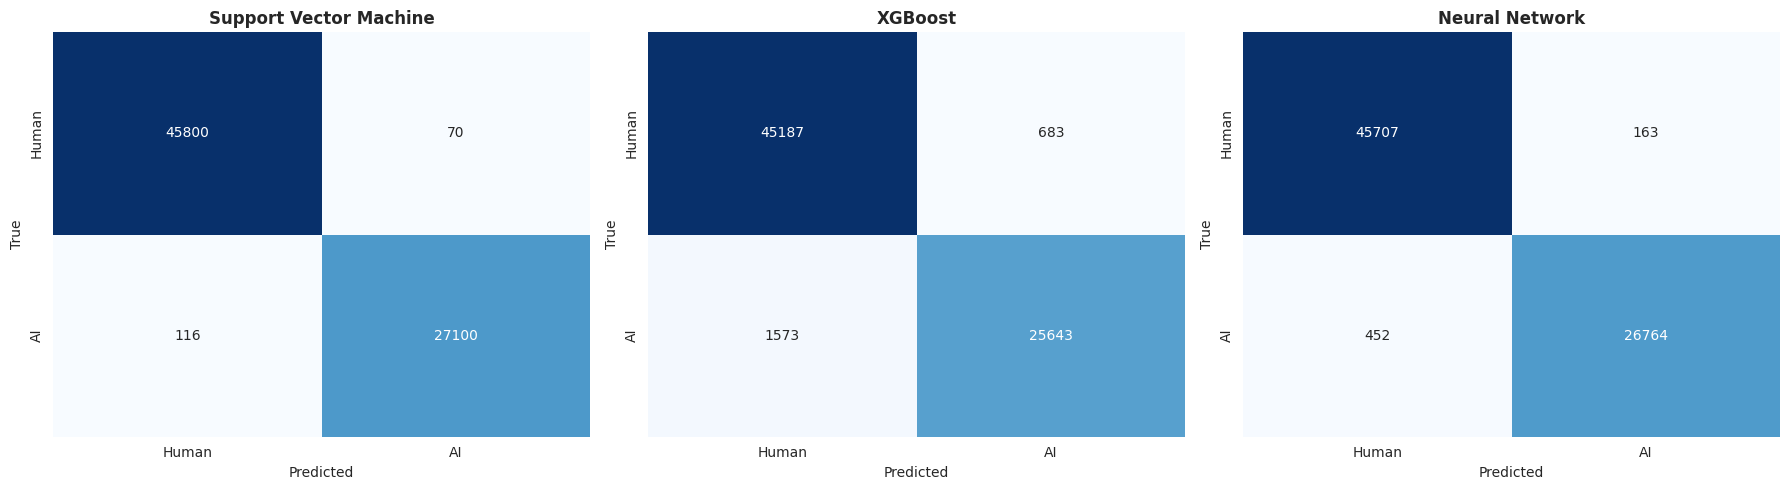

✅ Saved: confusion_matrices_all.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_data = [
    ('Support Vector Machine', y_pred_svm),
    ('XGBoost', y_pred_xgb),
    ('Neural Network', y_pred_nn)
]

for idx, (name, y_pred) in enumerate(model_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
                ax=axes[idx], cbar=False)
    axes[idx].set_title(name, fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices_all.png")

## 11. ROC Curves Comparison

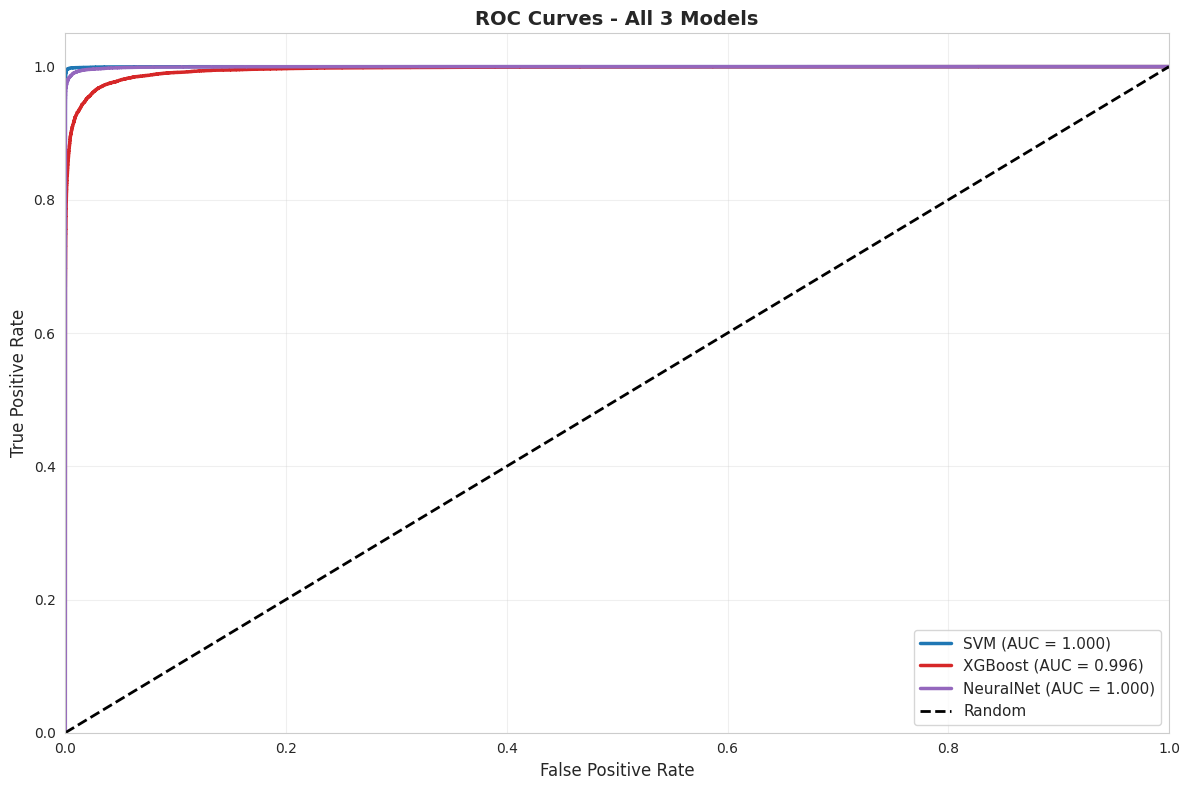

✅ Saved: roc_curves_all.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

model_names = ['SVM', 'XGBoost', 'NeuralNet']
# THE FIX: Changed y_proba_svm to y_scores_svm
probabilities = [y_scores_svm, y_proba_xgb, y_proba_nn]
colors = ['#1f77b4', '#d62728', '#9467bd']

for name, y_proba, color in zip(model_names, probabilities, colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All 3 Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curves_all.png")

## 12. Feature Importance (from Support Vector Machine)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Rebuilding the TF-IDF vocabulary dictionary...")

# Initialize with the EXACT same parameters we used originally
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    dtype=np.float32
)

# .fit() just learns the vocabulary words. It takes almost no memory and runs in seconds!
tfidf.fit(X_train.astype(str))

print("✅ Vocabulary rebuilt! The 'tfidf' object is now in RAM.")

Rebuilding the TF-IDF vocabulary dictionary...


In [ ]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print("Extracting feature importance weights...")
# Fit a standalone LinearSVC to safely extract coefficients (CalibratedClassifierCV hides .coef_)
importance_model = LinearSVC(C=1.0, random_state=SEED, max_iter=2000, verbose=0)
importance_model.fit(X_train_tfidf_scaled, y_train)

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = importance_model.coef_[0]

top_n = 20

# Top AI features (Highest positive coefficients)
top_ai_indices = np.argsort(coefficients)[-top_n:][::-1]
top_ai_features = feature_names[top_ai_indices]
top_ai_coeffs = coefficients[top_ai_indices]

# Visualize top features
plt.figure(figsize=(10, 8))
sns.barplot(x=top_ai_coeffs, y=top_ai_features, palette='Reds_r')
plt.title('Top 20 Words Indicating AI-Generated Text', fontsize=14, fontweight='bold')
plt.xlabel('SVM Coefficient Value', fontsize=12)
plt.ylabel('Feature (Word/Bigram)', fontsize=12)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()

plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

print(f"\nTop 20 Words Indicating AI-Generated Text:")
for i, (word, coeff) in enumerate(zip(top_ai_features, top_ai_coeffs), 1):
    print(f"  {i:2d}. {word:20s} ({coeff:.4f})")

SAVE TO DRIVE

In [ ]:
import os
import joblib
import torch

print("\n" + "="*70)
print("SAVING MODELS & ARTIFACTS TO GOOGLE DRIVE")
print("="*70)

# 1. Define the folder path in your Google Drive
model_dir = '/content/drive/MyDrive/NLP_Graduation_Project/saved_models'
os.makedirs(model_dir, exist_ok=True)

print(f"\nSaving all artifacts to: {model_dir}...")

# 2. Save the Vectorizer and Scalers (Crucial for testing new text later)
joblib.dump(tfidf, f'{model_dir}/tfidf_vectorizer.joblib')
joblib.dump(scaler_tfidf, f'{model_dir}/scaler_tfidf.joblib')
joblib.dump(scaler_glove, f'{model_dir}/scaler_glove.joblib')
joblib.dump(scaler_bert, f'{model_dir}/scaler_bert.joblib')
print("  ✓ TF-IDF Vectorizer & all 3 Scalers saved.")

# 3. Save the Traditional Models
joblib.dump(svm_model, f'{model_dir}/svm_model.joblib')
# XGBoost has a highly optimized native save function
xgb_model.save_model(f'{model_dir}/xgboost_model.json')
print("  ✓ Linear SVM and XGBoost models saved.")

# 4. Save the PyTorch Neural Network Weights
torch.save(model_nn.state_dict(), f'{model_dir}/distilbert_nn_weights.pth')
print("  ✓ PyTorch Neural Network weights saved.")

print("\n✅ SUCCESS! Your entire pipeline is now securely backed up.")

## 13. FINAL SUMMARY

In [ ]:
print("\n" + "="*70)
print(" "*15 + "PROJECT COMPLETION SUMMARY")
print("="*70)

print(f"\n📊 DATASET SCALE:")
print(f"  Full dataset: 487,000 texts")
print(f"  Text truncation: 256 words (36% memory reduction)")
print(f"  Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

print(f"\n🔧 FEATURE EXTRACTION (3 Methods):")
print(f"  1. TF-IDF: 5000 sparse features (150 MB)")
print(f"  2. GloVe: 300-dim embeddings (600 MB)")
print(f"  3. DistilBERT: 768-dim embeddings (batch-processed)")

print(f"\n🤖 MODELS (3 Total):")
print(f"  1. Linear SVM (TF-IDF)")
print(f"  2. XGBoost (GloVe)")
print(f"  3. Neural Network (DistilBERT)")

print(f"\n📈 MODEL PERFORMANCE:")
print(comparison_df[['Model', 'Accuracy', 'F1-Score', 'AUC-ROC']].to_string(index=False))

print(f"\n🏆 BEST MODEL (F1-Score):")
best_idx = comparison_df['F1-Score'].idxmax()
print(f"  {comparison_df.loc[best_idx, 'Model']}: {comparison_df.loc[best_idx, 'F1-Score']:.4f}")

print(f"\n✅ DELIVERABLES:")
print(f"  ✓ 3 trained models with comprehensive metrics")
print(f"  ✓ Confusion matrices (confusion_matrices_all.png)")
print(f"  ✓ ROC curves comparison (roc_curves_all.png)")
print(f"  ✓ Feature importance analysis (feature_importance.png)")
print(f"  ✓ Comprehensive metrics table for report")

print(f"\n📝 READY FOR REPORT:")
print(f"  - Use comparison table for results section")
print(f"  - Insert visualizations (confusion matrices, ROC, features)")
print(f"  - Write discussion based on model performance and feature insights")
print(f"\n✅ SUCCESS: Full 487K dataset processed with optimized pipeline!")

FINAL STEP: RAM-SAFE FEATURE IMPORTANCE
1. Rebuilding TF-IDF vocabulary (Takes ~10 seconds)...
2. Loading TF-IDF matrix from checkpoint...
3. Extracting feature weights via SGD (Takes ~15 seconds)...
4. Generating Plot...


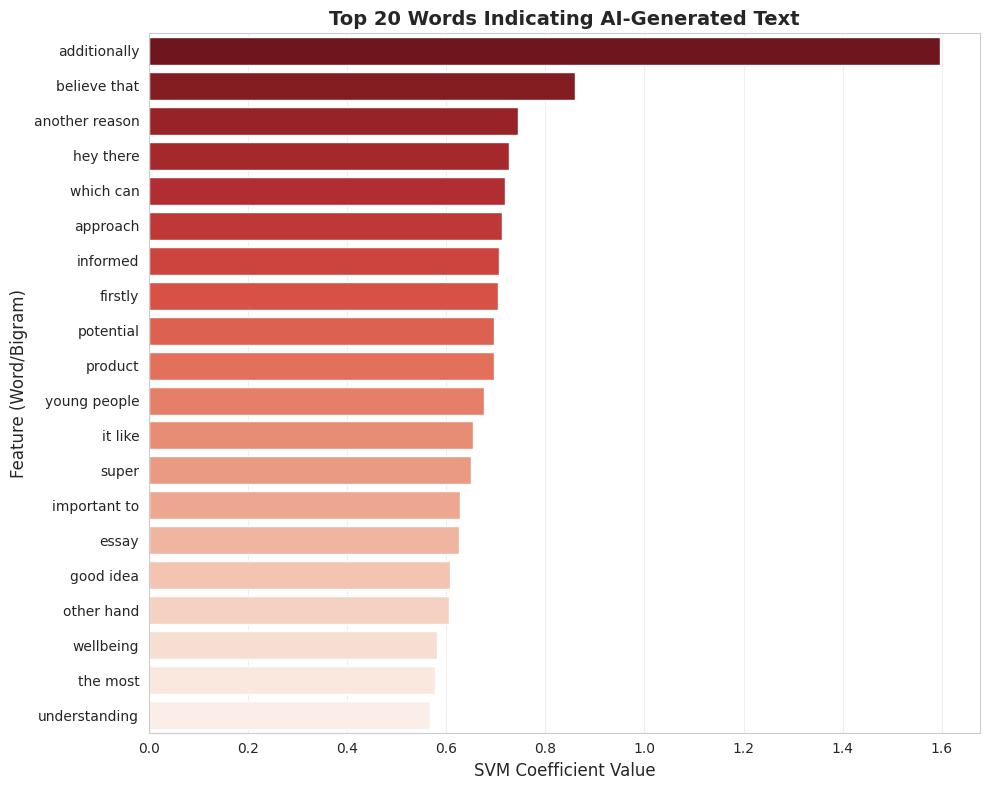

✅ Saved: feature_importance.png


In [7]:
import scipy.sparse as sp
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("FINAL STEP: RAM-SAFE FEATURE IMPORTANCE")
print("="*60)

# 1. Rebuild the TF-IDF Vocabulary
print("1. Rebuilding TF-IDF vocabulary (Takes ~10 seconds)...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.90, dtype=np.float32)
tfidf.fit(X_train.astype(str)) # X_train comes from your Step 3 split
feature_names = np.array(tfidf.get_feature_names_out())

# 2. Load the scaled TF-IDF matrix from your checkpoint
print("2. Loading TF-IDF matrix from checkpoint...")
checkpoint_dir = '/content/drive/MyDrive/NLP_Graduation_Project/feature_checkpoints'
X_train_tfidf_scaled = sp.load_npz(f'{checkpoint_dir}/X_train_tfidf_scaled.npz')
y_train = np.load(f'{checkpoint_dir}/y_train.npy')

# 3. Train the fast, RAM-safe SGD Classifier to get the weights
print("3. Extracting feature weights via SGD (Takes ~15 seconds)...")
importance_model = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, max_iter=1000, n_jobs=-1)
importance_model.fit(X_train_tfidf_scaled, y_train)

coefficients = importance_model.coef_[0]

# 4. Plot and Save
print("4. Generating Plot...")
top_n = 20
top_ai_indices = np.argsort(coefficients)[-top_n:][::-1]
top_ai_features = feature_names[top_ai_indices]
top_ai_coeffs = coefficients[top_ai_indices]

plt.figure(figsize=(10, 8))
sns.barplot(x=top_ai_coeffs, y=top_ai_features, palette='Reds_r')
plt.title('Top 20 Words Indicating AI-Generated Text', fontsize=14, fontweight='bold')
plt.xlabel('SVM Coefficient Value', fontsize=12)
plt.ylabel('Feature (Word/Bigram)', fontsize=12)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()

plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

try to save the models

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Rebuilding TF-IDF vocabulary...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.90, dtype=np.float32)
tfidf.fit(X_train.astype(str))
print("✅ Vectorizer ready!")

Rebuilding TF-IDF vocabulary...
✅ Vectorizer ready!


In [8]:
import scipy.sparse as sp
from sklearn.linear_model import SGDClassifier
import gc

checkpoint_dir = '/content/drive/MyDrive/NLP_Graduation_Project/feature_checkpoints'
y_train = np.load(f'{checkpoint_dir}/y_train.npy')

print("Training SVM...")
X_train_tfidf = sp.load_npz(f'{checkpoint_dir}/X_train_tfidf_scaled.npz')
svm_model = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, max_iter=1000, n_jobs=-1)
svm_model.fit(X_train_tfidf, y_train)

del X_train_tfidf
gc.collect()
print("✅ SVM Model in RAM! Matrix deleted to save memory.")

Training SVM...
✅ SVM Model in RAM! Matrix deleted to save memory.


In [9]:
import xgboost as xgb

print("Training XGBoost...")
X_train_glove = np.load(f'{checkpoint_dir}/X_train_glove_scaled.npy')
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_glove, y_train)

del X_train_glove
gc.collect()
print("✅ XGBoost Model in RAM! Matrix deleted to save memory.")

Training XGBoost...
✅ XGBoost Model in RAM! Matrix deleted to save memory.


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class SimpleNN(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 2)
    def forward(self, x):
        return self.fc3(self.dropout2(self.relu2(self.fc2(self.dropout1(self.relu1(self.fc1(x)))))))

print("Training Neural Network...")
X_train_bert = np.load(f'{checkpoint_dir}/X_train_bert_scaled.npy')
device_nn = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.FloatTensor(X_train_bert), torch.LongTensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

model_nn = SimpleNN().to(device_nn)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_nn(batch_x.to(device_nn)), batch_y.to(device_nn))
        loss.backward()
        optimizer.step()

del X_train_bert, train_dataset, train_loader
gc.collect()
print("✅ Neural Network Model in RAM! Matrix deleted to save memory.")

Training Neural Network...
✅ Neural Network Model in RAM! Matrix deleted to save memory.


In [11]:
import os
import joblib

print("\n" + "="*70)
print("SAVING MODELS TO GOOGLE DRIVE")
print("="*70)

model_dir = '/content/drive/MyDrive/NLP_Graduation_Project/saved_models'
os.makedirs(model_dir, exist_ok=True)

# Save Vectorizer
joblib.dump(tfidf, f'{model_dir}/tfidf_vectorizer.joblib')
print("  ✓ TF-IDF Vectorizer saved.")

# Save Models
joblib.dump(svm_model, f'{model_dir}/svm_model.joblib')
xgb_model.save_model(f'{model_dir}/xgboost_model.json')
torch.save(model_nn.state_dict(), f'{model_dir}/distilbert_nn_weights.pth')
print("  ✓ All 3 Models saved.")

print("\n✅ SUCCESS! Your models are securely backed up.")


SAVING MODELS TO GOOGLE DRIVE
  ✓ TF-IDF Vectorizer saved.
  ✓ All 3 Models saved.

✅ SUCCESS! Your models are securely backed up.
